In [126]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pywt


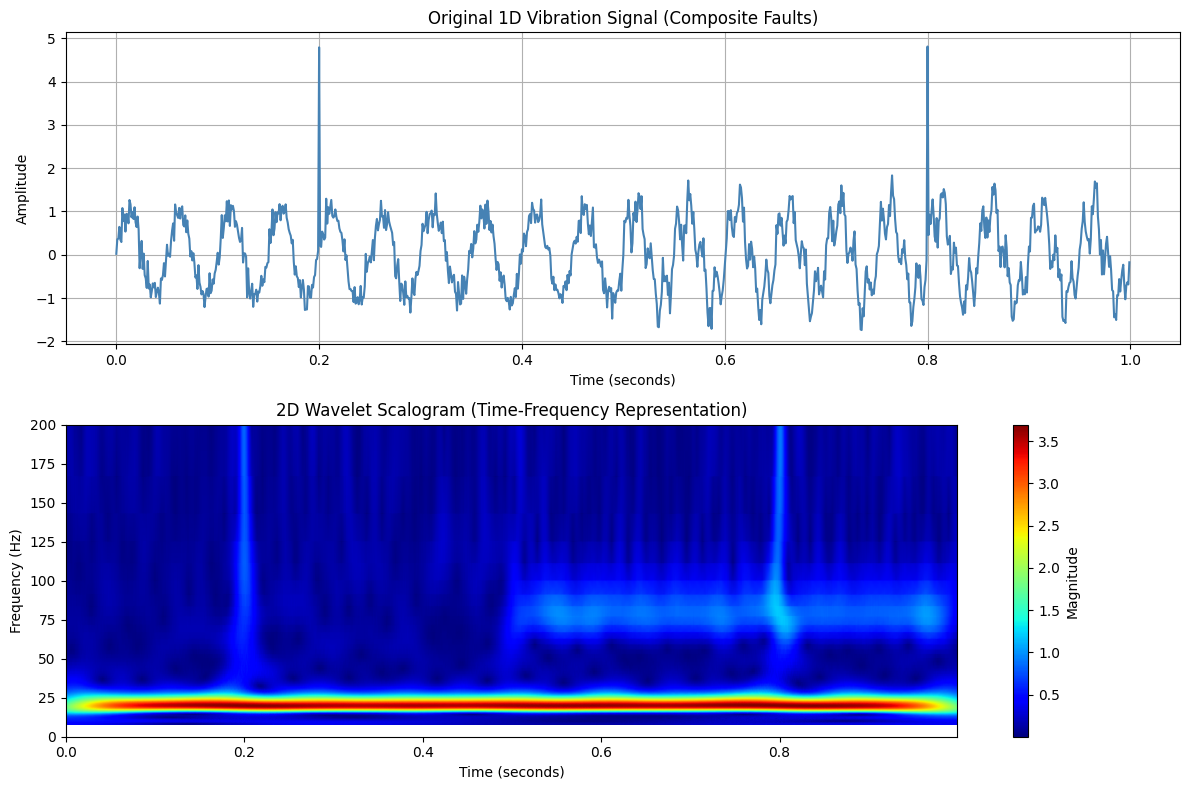

In [127]:

# ==========================================
# 第一步：生成模拟的“机器振动信号”
# ==========================================
# 采样频率和时间向量
fs = 1000  # 采样率 1000 Hz
t = np.linspace(0, 1, fs, endpoint=False) # 1秒钟的信号

# 1. 低频基线信号 (模拟机器正常运转的背景噪音，20Hz)
signal_normal = np.sin(2 * np.pi * 20 * t)

# 2. 高频突变信号 (模拟机器在 0.5秒 时突然发生的高频振动，80Hz)
signal_high_freq = np.zeros_like(t)
signal_high_freq[500:] = 0.5 * np.sin(2 * np.pi * 80 * t[500:]) 

# 3. 瞬态冲击信号 (模拟齿轮断齿或轴承裂纹在 0.2秒和 0.8秒时的瞬间撞击)
impacts = np.zeros_like(t)
impacts[200] = 5  # 0.2秒处的强冲击
impacts[800] = 5  # 0.8秒处的强冲击

# 合成最终的复合信号，并加入一点随机白噪声
signal_composite = signal_normal + signal_high_freq + impacts + np.random.normal(0, 0.2, len(t))

# ==========================================
# 第二步：执行连续小波变换 (CWT)
# ==========================================
# 选择小波基函数：这里选用复 Morlet 小波 ('cmor')，它在故障诊断中非常经典
wavelet_name = 'cmor1.5-1.0' 

# 定义我们要观察的尺度 (Scales)。尺度越小，对应频率越高；尺度越大，对应频率越低。
scales = np.arange(1, 128)

# 执行连续小波变换
# cwtmatr 包含了变换后的复数矩阵（即时频特征），frequencies 是对应的实际频率
coefficients, frequencies = pywt.cwt(signal_composite, scales, wavelet_name, sampling_period=1/fs)

# 取绝对值（振幅），用于可视化
amplitude_scalogram = np.abs(coefficients)

# ==========================================
# 第三步：可视化结果
# ==========================================
plt.figure(figsize=(12, 8))

# 绘制原始一维信号
plt.subplot(2, 1, 1)
plt.plot(t, signal_composite, color='steelblue')
plt.title("Original 1D Vibration Signal (Composite Faults)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# 绘制小波变换后的二维时频图 (Scalogram)

plt.subplot(2, 1, 2)
# 使用 pcolormesh 绘制热力图
plt.pcolormesh(t, frequencies, amplitude_scalogram, shading='gouraud', cmap='jet')
plt.title("2D Wavelet Scalogram (Time-Frequency Representation)")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Magnitude")
plt.ylim(0, 200) # 限制 Y 轴显示范围以便看得更清楚

plt.tight_layout()
plt.show()

In [128]:
file_path='../数据集/BJTU/外圈/data_leftaxlebox_M0_G0_LA2_RA0_20Hz_-10kN.csv'
def data_load(file_path):
    df=pd.read_csv(file_path,usecols=['CH17'])
    df=df.iloc[:,0].values
    return df

In [129]:
data=data_load(file_path)
data=data[:64000]

In [130]:
def wav_trans(fs,wavelet_name,data):
    # 选择小波基函数：这里选用复 Morlet 小波 ('cmor')，它在故障诊断中非常经典
    
    # 定义我们要观察的尺度 (Scales)。尺度越小，对应频率越高；尺度越大，对应频率越低。
    scales = np.arange(1, 128)
    
    # 执行连续小波变换
    # cwtmatr 包含了变换后的复数矩阵（即时频特征），frequencies 是对应的实际频率
    coefficients, frequencies = pywt.cwt(data, scales, wavelet_name, sampling_period=1/fs)
    
    # 取绝对值（振幅），用于可视化
    amplitude_scalogram = np.abs(coefficients)
    return  frequencies,amplitude_scalogram

In [131]:
fs=64000 #fs 采样频率

frequencies,amplitude_scalogram=wav_trans(fs,wavelet_name='cgau8',data=data)

In [132]:
# 绘制原始一维信号
def plot(data,frequencies,amplitude_scalogram):
    plt.subplot(2, 1, 1)
    t = np.linspace(0, 1, fs, endpoint=False)
    plt.plot(t, data, color='steelblue')
    plt.title("Original 1D Vibration Signal (Composite Faults)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    
    # 绘制小波变换后的二维时频图 (Scalogram)
    
    plt.subplot(2, 1, 2)
    # 使用 pcolormesh 绘制热力图
    plt.pcolormesh(t, frequencies, amplitude_scalogram, shading='gouraud', cmap='jet')
    plt.title("2D Wavelet Scalogram (Time-Frequency Representation)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Magnitude")
    plt.ylim(500,10000) # 把上限从 60000 多压到 15000 左右（可根据实际亮斑位置微调）
    
    plt.tight_layout()
    plt.show()

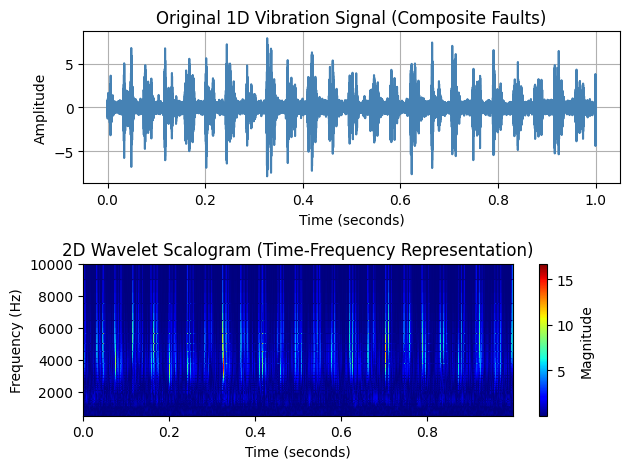

In [133]:
plot(data, frequencies, amplitude_scalogram)

In [ ]:


def file_process()